Archivos CSV extraídos y guardados en:
 -> C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\01_Sismos_PEER


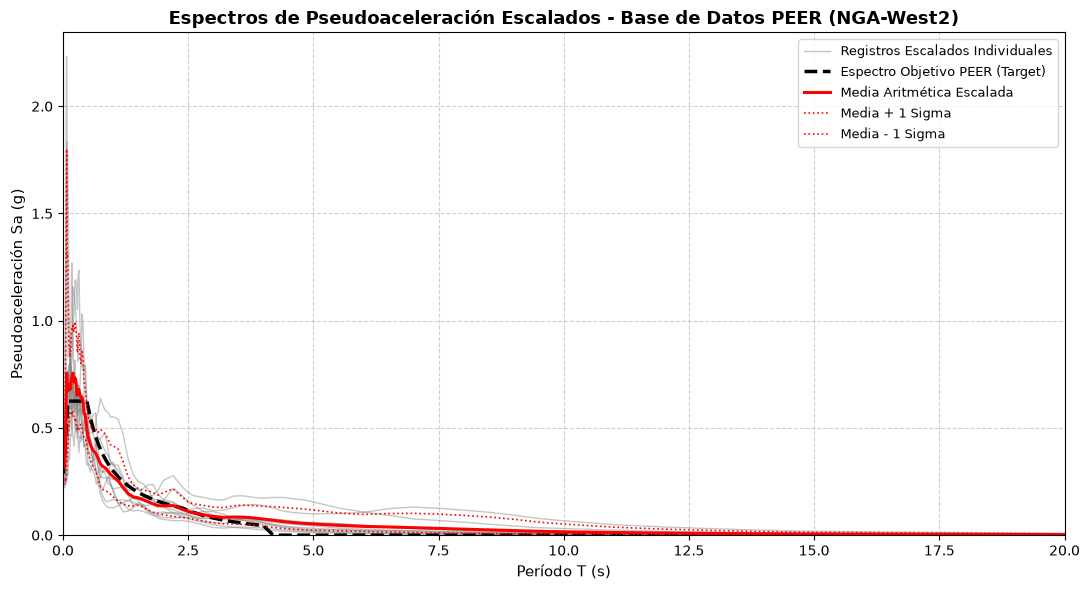

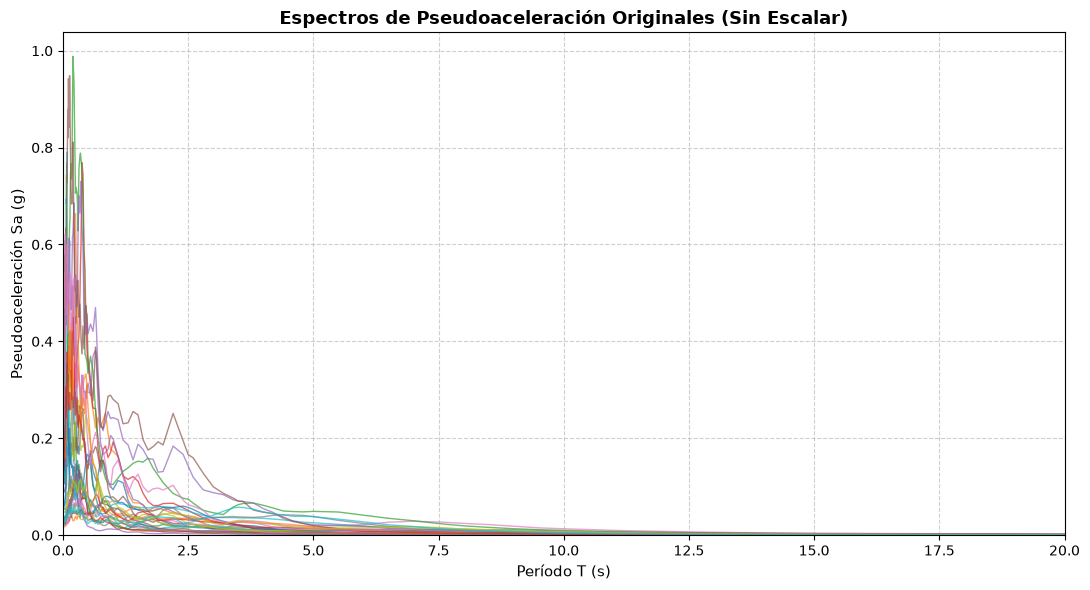


PROCESO COMPLETADO EXITOSAMENTE
Archivos creados en 'C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\01_Sismos_PEER':
  1. 01_Metadatos_Sismos_PEER.csv
  2. 02_Espectros_Escalados_PEER.csv
  3. 03_Espectros_SinEscalar_PEER.csv
  4. Grafica_Espectros_Escalados_PEER.png
  5. Grafica_Espectros_SinEscalar_PEER.png


In [1]:
import os
import io
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. RUTAS DE ENTRADA Y SALIDA
# =============================================================================
ruta_csv_origen = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\_SearchResults.csv"
dir_destino = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\01_Sismos_PEER"

os.makedirs(dir_destino, exist_ok=True)

# =============================================================================
# 2. LECTURA Y SEPARACIÓN DE SECCIONES DEL ARCHIVO PEER
# =============================================================================
with open(ruta_csv_origen, 'r', encoding='utf-8', errors='ignore') as f:
    contenido = f.read()

lineas = contenido.split('\n')

metadata_idx = None
scaled_idx = None
unscaled_idx = None

for i, line in enumerate(lineas):
    if '-- Summary of Metadata of Selected Records --' in line:
        metadata_idx = i + 1
    elif '-- Scaled Spectra used in Search & Scaling --' in line:
        scaled_idx = i + 1
    elif '-- Unscaled Horizontal & Vertical Spectra, as recorded --' in line:
        unscaled_idx = i + 1

# --- A) Extracción de Metadatos ---
meta_str = "\n".join(lineas[metadata_idx : scaled_idx - 2])
df_meta = pd.read_csv(io.StringIO(meta_str))
# Limpiar espacios en nombres de columnas
df_meta.columns = df_meta.columns.str.strip()

# --- B) Extracción de Espectros Escalados ---
scaled_str = "\n".join(lineas[scaled_idx : unscaled_idx - 2])
df_scaled = pd.read_csv(io.StringIO(scaled_str))
df_scaled.columns = df_scaled.columns.str.strip()

# --- C) Extracción de Espectros Sin Escalar ---
unscaled_str = "\n".join(lineas[unscaled_idx:])
df_unscaled = pd.read_csv(io.StringIO(unscaled_str))
df_unscaled.columns = df_unscaled.columns.str.strip()

# =============================================================================
# 3. EXPORTACIÓN DE ARCHIVOS DENTRO DE LA CARPETA DE DESTINO
# =============================================================================
path_csv_meta = os.path.join(dir_destino, "01_Metadatos_Sismos_PEER.csv")
path_csv_scaled = os.path.join(dir_destino, "02_Espectros_Escalados_PEER.csv")
path_csv_unscaled = os.path.join(dir_destino, "03_Espectros_SinEscalar_PEER.csv")

df_meta.to_csv(path_csv_meta, index=False)
df_scaled.to_csv(path_csv_scaled, index=False)
df_unscaled.to_csv(path_csv_unscaled, index=False)

print(f"Archivos CSV extraídos y guardados en:\n -> {dir_destino}")

# =============================================================================
# 4. GRAFICACIÓN Y GUARDADO DE ESPECTROS ESCALADOS
# =============================================================================
plt.figure(figsize=(11, 6))

periodos = df_scaled['Period (sec)']
col_rsn = [c for c in df_scaled.columns if 'RSN-' in c]

# Registros individuales escalados (Líneas grises delgadas)
for i, col in enumerate(col_rsn):
    label_ind = 'Registros Escalados Individuales' if i == 0 else "_nolegend_"
    plt.plot(periodos, df_scaled[col], color='gray', alpha=0.45, linewidth=1.0, label=label_ind)

# Espectro Objetivo (Target Spectrum)
if 'Target pSa (g)' in df_scaled.columns:
    plt.plot(periodos, df_scaled['Target pSa (g)'], 'k--', linewidth=2.5, label='Espectro Objetivo PEER (Target)')

# Media Aritmética Escalada
if 'Arithmetic Mean pSa (g)' in df_scaled.columns:
    plt.plot(periodos, df_scaled['Arithmetic Mean pSa (g)'], 'r-', linewidth=2.2, label='Media Aritmética Escalada')

# Desviación Estándar (+/- 1 Sigma)
if 'Arithmetic Mean + Sigma pSa (g)' in df_scaled.columns:
    plt.plot(periodos, df_scaled['Arithmetic Mean + Sigma pSa (g)'], 'r:', linewidth=1.2, label='Media + 1 Sigma')
if 'Arithmetic Mean - Sigma pSa (g)' in df_scaled.columns:
    plt.plot(periodos, df_scaled['Arithmetic Mean - Sigma pSa (g)'], 'r:', linewidth=1.2, label='Media - 1 Sigma')

plt.title('Espectros de Pseudoaceleración Escalados - Base de Datos PEER (NGA-West2)', fontsize=13, fontweight='bold')
plt.xlabel('Período T (s)', fontsize=11)
plt.ylabel('Pseudoaceleración Sa (g)', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=9.5)
plt.xlim(0, max(periodos))
plt.ylim(bottom=0)
plt.tight_layout()

path_img_scaled = os.path.join(dir_destino, "Grafica_Espectros_Escalados_PEER.png")
plt.savefig(path_img_scaled, dpi=300)
plt.show()

# =============================================================================
# 5. GRAFICACIÓN Y GUARDADO DE ESPECTROS SIN ESCALAR (ORIGINALES)
# =============================================================================
plt.figure(figsize=(11, 6))

periodos_un = df_unscaled['Period (sec)']
col_unscaled_sa = [c for c in df_unscaled.columns if c != 'Period (sec)']

for col in col_unscaled_sa:
    plt.plot(periodos_un, df_unscaled[col], linewidth=1.0, alpha=0.7, label=col)

plt.title('Espectros de Pseudoaceleración Originales (Sin Escalar)', fontsize=13, fontweight='bold')
plt.xlabel('Período T (s)', fontsize=11)
plt.ylabel('Pseudoaceleración Sa (g)', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
if len(col_unscaled_sa) <= 12:
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.xlim(0, max(periodos_un))
plt.ylim(bottom=0)
plt.tight_layout()

path_img_unscaled = os.path.join(dir_destino, "Grafica_Espectros_SinEscalar_PEER.png")
plt.savefig(path_img_unscaled, dpi=300)
plt.show()

print("\n" + "="*80)
print("PROCESO COMPLETADO EXITOSAMENTE")
print("="*80)
print(f"Archivos creados en '{dir_destino}':")
print("  1. 01_Metadatos_Sismos_PEER.csv")
print("  2. 02_Espectros_Escalados_PEER.csv")
print("  3. 03_Espectros_SinEscalar_PEER.csv")
print("  4. Grafica_Espectros_Escalados_PEER.png")
print("  5. Grafica_Espectros_SinEscalar_PEER.png")